<a href="https://colab.research.google.com/github/Manojmp7676/DEEP_LEARNING_FILES/blob/main/exp_4_DL_Enc_dec_autoenc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective

To build a Convolutional Autoencoder (CAE) that compresses facial images into a lower-dimensional latent representation and reconstructs them with minimal loss of information.

Purpose

A Convolutional Autoencoder is an unsupervised deep learning model used for:

* Image Compression
* Image Reconstruction
* Feature Extraction
* Dimensionality Reduction

The encoder learns a compressed representation (latent space), while the decoder reconstructs the original image from this compressed representation.


In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [2]:
!pip install -q kaggle

In [3]:
import kagglehub
path=kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [4]:
# Create a Smaller Dataset (5000 Images)

source_folder = os.path.join(path,"img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )
print("copied",len(images),"images")


copied 5000 images


In [5]:
#data preprocessing
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

In [6]:
datagen=ImageDataGenerator(
    rescale=1./255,
validation_split=0.2
)

In [7]:
#load DAtaset
train_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE, #resizeing the every image to the same size
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [8]:
validation_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


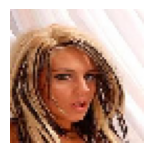

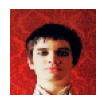

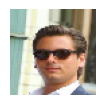

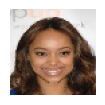

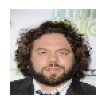

In [9]:
#display sample images
images,_=next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.show()


In [10]:
#build convolution autoencoder
#Encoder
input_img=Input(shape=(64,64,3))
x=Conv2D(32,(3,3),activation="relu",padding="same")(input_img)#32 we are assigning the filter each will check its head ,color and all
x=MaxPooling2D((2,2),padding="same")(x) # max number we will select
encoder=MaxPooling2D((2,2),padding="same")(x)

In [11]:
#decoder
x=Conv2D(32,(3,3),activation="relu",padding="same")(encoder)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation="relu",padding="same")(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(3,(3,3),activation="sigmoid",padding="same")(x)

In [13]:
autoencoder = Model(inputs=input_img, outputs=decoded)

In [14]:
#compile model
autoencoder.compile(
    optimizer="adam", # Adam predict the weight of the model
    loss="binary_crossentropy"# where the target has only two classes
)

In [15]:
#model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,259 (79.14 KB)

 Trainable params: 20,259 (79.14 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#train model
history = autoencoder.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 350ms/step - loss: 0.5414 - val_loss: 0.5030
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 346ms/step - loss: 0.4989 - val_loss: 0.4975
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 365ms/step - loss: 0.4949 - val_loss: 0.4937
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 347ms/step - loss: 0.4932 - val_loss: 0.4966
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 347ms/step - loss: 0.4924 - val_loss: 0.4915


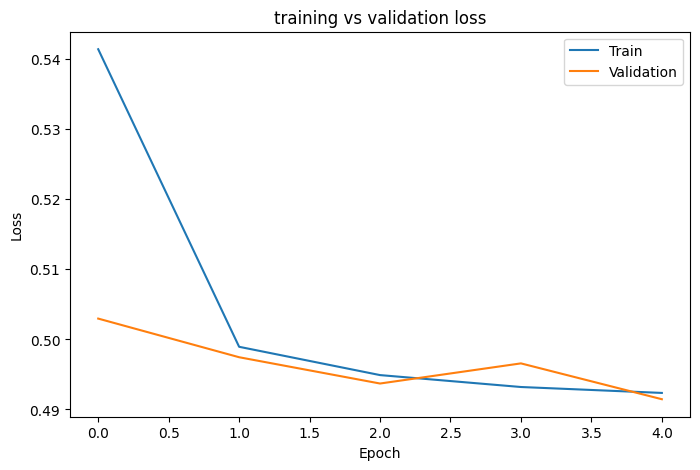

In [17]:
#plot the loss graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('training vs validation loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [18]:
#evaluate Model
loss=autoencoder.evaluate(validation_generator)
print("Validation Loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.4915
Validation Loss: 0.4914594292640686


In [19]:
#reconstruct Images
images,_=next(validation_generator)
reconstructed_images=autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step


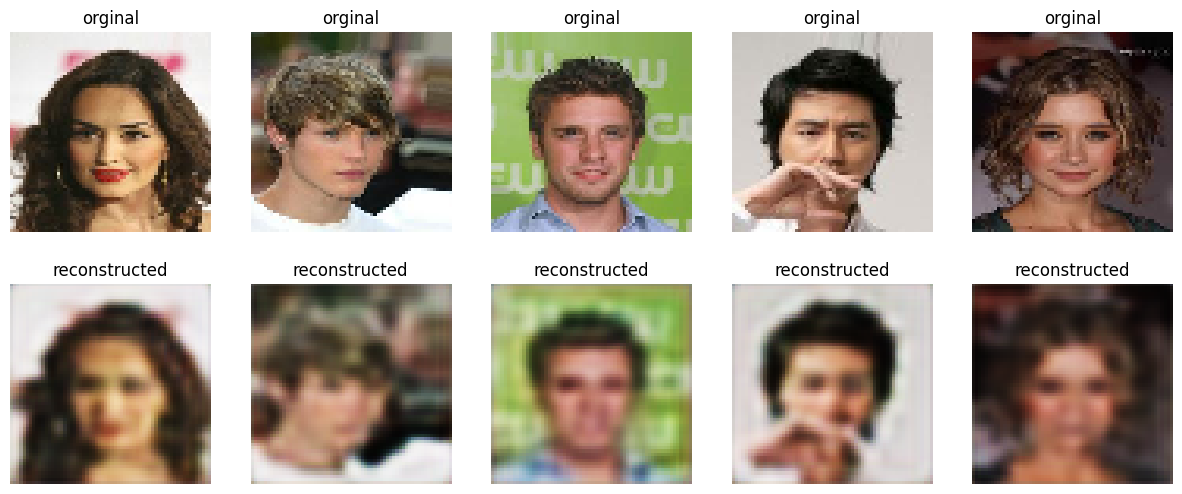

In [29]:
#Display result
n=5
plt.figure(figsize=(15,6))
for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(images[i])
    plt.title("orginal")
    plt.axis("off")
    plt.subplot(2,n,i+1+n)
    plt.imshow(reconstructed_images[i])
    plt.title("reconstructed")
    plt.axis("off")
plt.show()